In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 


In [2]:
df=pd.read_csv("Rajshahi-Srimongals.csv")

In [3]:
dff=df.copy()

In [4]:


data_raj=dff[dff['Region']=='Rajshahi']
data_sri=dff[dff['Region']=='Srimongal']


In [5]:
df_raj=data_raj[['Temperature', 'ST-10', 'ST-30', 'ST-50']]
df_sri=data_sri[['Temperature', 'ST-10', 'ST-30', 'ST-50']]

In [6]:
df_sri.sample()

,Temperature,ST-10,ST-30,ST-50
3010,25.4,27.1,27.8,26.75


# Rajshahi Linear Regression

In [7]:
import math

m = len(df_raj)

train_end_raj = math.floor(m * 0.80)

train_raj = df_raj.iloc[:train_end_raj]
val_raj = df_raj.iloc[train_end_raj:]


In [8]:
X_train_raj=train_raj[['Temperature']]
y_train_raj=train_raj[['ST-50']]

X_val_raj=val_raj[['Temperature']]
y_val_raj=val_raj[['ST-50']]


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [10]:
lr_raj=LinearRegression()
lr_raj.fit(X_train_raj,y_train_raj)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_raj_pred=lr_raj.predict(X_val_raj)

In [12]:
mae_raj=mean_absolute_error(y_val_raj,y_raj_pred)
mae_raj

1.0856107569537208

In [13]:
mse_raj=mean_squared_error(y_val_raj,y_raj_pred)
mse_raj

2.0570963407768503

In [14]:
r2_raj=r2_score(y_val_raj,y_raj_pred)
r2_raj

0.8895295278405484

In [15]:
m_raj=lr_raj.coef_[0][0]
m_raj

0.8291081275832363

In [16]:
c_raj=lr_raj.intercept_[0]
c_raj

6.498126376743244

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_15424\1343034362.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_raj.min(), y_val_raj.max()],
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_15424\1343034362.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')


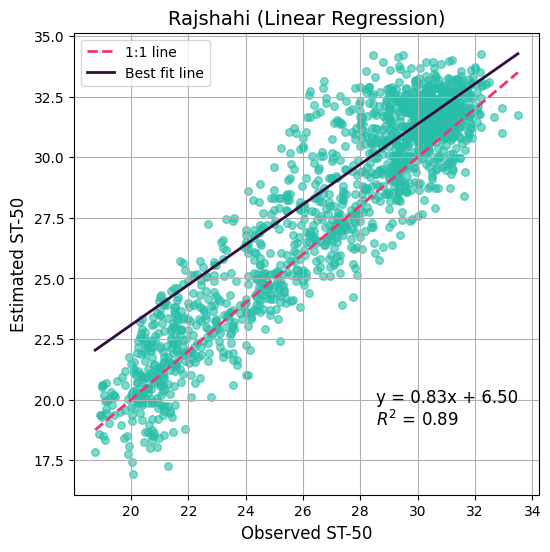

In [32]:

plt.figure(figsize=(6,6))
plt.scatter(y_val_raj, y_raj_pred,s=30, alpha=0.6,c='#29BEA9')
plt.plot([y_val_raj.min(), y_val_raj.max()],
         [y_val_raj.min(), y_val_raj.max()],
         'r--', lw=2, label="1:1 line",c='#ed3572')

x_vals = np.linspace(y_val_raj.min(), y_val_raj.max(), 100)
plt.plot(x_vals, m_raj * x_vals + c_raj, 'b-', lw=2, label="Best fit line",c='#320d3e')

plt.text(0.65, 0.2, f'y = {m_raj:.2f}x + {c_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_raj:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-50', fontsize=12)
plt.ylabel('Estimated ST-50', fontsize=12)
plt.title('Rajshahi (Linear Regression)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


# Srimongal Linear Regression 

In [21]:
import math

m = len(df_sri)

train_end_sri = math.floor(m * 0.80)

train_sri = df_sri.iloc[:train_end_sri]
val_sri = df_sri.iloc[train_end_sri:]


X_train_sri=train_sri[['Temperature']]
y_train_sri=train_sri[['ST-50']]

X_val_sri=val_sri[['Temperature']]
y_val_sri=val_sri[['ST-50']]


In [22]:
val_sri.shape

(1607, 4)

In [23]:
Q1 = X_train_sri['Temperature'].quantile(0.25)
Q3 = X_train_sri['Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_15424\970763780.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sri['Temperature'] = X_train_sri['Temperature'].clip(lower=lower_bound, upper=upper_bound)


In [25]:
X_train_sri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6428 entries, 0 to 6427
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  6428 non-null   float64
dtypes: float64(1)
memory usage: 100.4 KB


In [26]:
lr_sri = LinearRegression()
lr_sri.fit(X_train_sri, y_train_sri)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
y_sri_pred=lr_sri.predict(X_val_sri)
mae_sri=mean_absolute_error(y_val_sri,y_sri_pred)
mse_sri=mean_squared_error(y_val_sri,y_sri_pred)
r2_sri=r2_score(y_val_sri,y_sri_pred)

In [28]:
print(mae_sri,mse_sri,r2_sri)

0.9155776693841161 1.4486648054826627 0.8994415001282907


In [29]:
m_sri=lr_sri.coef_[0][0]
m_sri

0.7320027064204051

In [30]:
c_sri=lr_sri.intercept_[0]
c_sri

8.880008912190043

C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_15424\1131173369.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_val_sri.min(), y_val_sri.max()],
C:\Users\HP Laptop 15\AppData\Local\Temp\ipykernel_15424\1131173369.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')


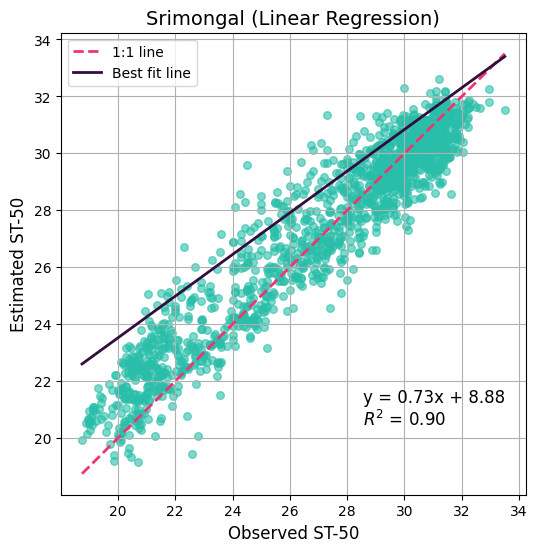

In [31]:

plt.figure(figsize=(6,6))
plt.scatter(y_val_sri, y_sri_pred,s=30, alpha=0.6,c='#29BEA9')
plt.plot([y_val_sri.min(), y_val_sri.max()],
         [y_val_sri.min(), y_val_sri.max()],
         'r--', lw=2, label="1:1 line",c='#ed3572')

x_vals_sri = np.linspace(y_val_sri.min(), y_val_sri.max(), 100)
plt.plot(x_vals_sri, m_sri * x_vals_sri + c_sri, 'b-', lw=2, label="Best fit line" ,c='#320d3e')

plt.text(0.65, 0.2, f'y = {m_sri:.2f}x + {c_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)
plt.text(0.65, 0.15, f'$R^2$ = {r2_sri:.2f}', transform=plt.gca().transAxes, fontsize=12)

plt.xlabel('Observed ST-50', fontsize=12)
plt.ylabel('Estimated ST-50', fontsize=12)
plt.title('Srimongal (Linear Regression)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
